# MassSpecGym retrieval evaluation on S4 candidates — final results

We evaluate **spectrum-free** SMILES-only baselines (chirality count and
ChemBERTa-77M-MLM binary classifier) on the S4-augmented retrieval
candidates. Spectrum-free models score above random *only if* the
candidate set encodes a shortcut — that's the failure mode in *Skinnider
et al., "Confronting spurious evaluations of computational methods in
small molecule mass spectrometry"* (bioRxiv 2026.05.03.722532).

This notebook is the **final consolidated report**, replacing two earlier
incorrect versions. The story:

1. **A real spurious shortcut existed in the stereo-preserving candidates.**
   S4's 38-token tokenizer (inherited from ChEMBL31) has no stereo tokens —
   all S4 candidates are stereo-free by construction. MSG queries carry
   stereo. Models trivially exploit that asymmetry.
2. **Stereo-stripping fixes it.** With both queries and candidates
   non-isomeric, the chirality-count baseline collapses to random; ChemBERTa
   formula collapses to ~random; ChemBERTa mass keeps a modest residual
   (5.6× random) which is not explained by any single feature.

Utility for stripping stereo is now in `massspecgym.utils.strip_stereo` and
`strip_stereo_{tsv,mgf,candidates_json}` (so it can be re-applied to .tsv,
.mgf, and any candidate JSON consistently).

## What went wrong during this analysis (and the fixes)

Three issues were caught — in chronological order:

1. **Wrong random baseline.** I quoted `1/1024 = 0.098%` as random
   throughout, but candidate lists have **variable length** (formula final:
   median 513, mean 552, range 8–1024). The correct random baseline is
   `mean(1/N_i)` over test queries — **1.35% for formula, 0.28% for
   mass**. Every ratio I reported earlier (anything labelled "×random")
   was inflated by 5–10×. All numbers below use the correct baseline.

2. **Tie-breaking bug in `eval_chirality_baseline.py`.** Original
   implementation used stable `np.argsort` on candidate scores. With the
   GT always at index 0 and all-zero scores (e.g. after stripping stereo
   when all `chir_count = 0`), stable sort placed the GT first → spurious
   100% hit@k. Inflated the **stereo-formula chirality hit@1 from 22% →
   92%**. Fixed in v2 of the script by adding `rng.random(N) * 1e-9`
   jitter to break ties uniformly.

3. **I over-claimed about the residual signal.** After stereo-stripping,
   ChemBERTa formula gives 1.48% hit@1. I called this an "in-distribution
   gap, acceptable". Roman pushed back — under the correct random baseline
   (1.35%), 1.48% is **1.10×**, indistinguishable from random.

The plumbing is now solid. The numbers in section 2 below are the ones
to trust.

## Final consolidated results table

Spectrum-free baselines, MSG test fold (n=2,996 unique queries after
stereo-stripping). All numbers are hit@k as percentages; ratios are
`baseline / random` (where random is `mean(1/N_i)`, accounting for
variable candidate-list size).

| Baseline                       | Variant | Setting   | hit@1   | random   | × random |
|--------------------------------|---------|-----------|---------|----------|----------|
| **Random (theoretical)**       | formula | stereo    | —       | 0.075%   | 1.00×    |
| **Random (theoretical)**       | formula | nostereo  | —       | 1.345%   | 1.00×    |
| **Random (theoretical)**       | mass    | stereo    | —       | 0.114%   | 1.00×    |
| **Random (theoretical)**       | mass    | nostereo  | —       | 0.285%   | 1.00×    |
| Chirality count                | formula | stereo    | 22.40%  | 0.075%   | **~298×**|
| Chirality count                | formula | nostereo  | 1.04%   | 1.345%   | **0.77×**|
| Chirality count                | mass    | stereo    | 25.56%  | 0.114%   | **~224×**|
| Chirality count                | mass    | nostereo  | 0.33%   | 0.285%   | **1.18×**|
| ChemBERTa-77M-MLM              | formula | stereo    | (stuck) | 0.075%   | —        |
| ChemBERTa-77M-MLM              | formula | nostereo  | 1.48%   | 1.345%   | **1.10×**|
| ChemBERTa-77M-MLM              | mass    | stereo    | 6.27%   | 0.114%   | **~55×** |
| ChemBERTa-77M-MLM              | mass    | nostereo  | 1.57%   | 0.285%   | **5.6×** |

**Single-feature ranking baselines** (sanity probes) on the **nostereo**
final variants — to check whether any obvious one-line property of the
SMILES still acts as a shortcut.

| Feature                | formula nostereo (×random) | mass nostereo (×random) |
|------------------------|----------------------------|--------------------------|
| aromatic_atoms (asc)   | 1.49×                      | 1.41×                    |
| n_rings (asc)          | 1.31×                      | 1.41×                    |
| heavy_atoms (asc)      | 1.29×                      | 0.59×                    |
| heteroatoms (asc)      | 1.02×                      | 1.06×                    |
| n_unusual_elements     | 0.87×                      | 1.41×                    |
| max_ring_size          | 1.17×                      | 1.41×                    |
| n_nitrogens            | 0.69×                      | 1.41×                    |
| length (asc)           | 0.59×                      | 0.35×                    |

**Conclusions:**

- **Stereo-stripping fixes the dominant shortcut.** All ~50–300× ratios
  in the stereo-preserving column collapse to ~1× (random) or low single
  digits in the nostereo column.
- **Chirality nostereo is random** (Roman called this correctly).
- **ChemBERTa formula nostereo is essentially random** (1.10×). Formula
  candidates look in-distribution to the model.
- **ChemBERTa mass nostereo at 5.6× random is the only remaining
  spectrum-free signal.** Not explained by any single feature (max
  single-feature ratio is 1.41×). Likely picks up sequence-level
  patterns (n-gram frequencies, specific substructure tokens) — i.e.
  multi-feature combinations the simple ranking baselines miss. This is
  small in absolute terms (1.57% vs 0.28%) but worth a future
  investigation if mass-based retrieval becomes a primary benchmark.
- **PubChem augmentation healed a real shortcut on mass.** The
  `heavy_atoms` per-step ablation goes 1.84× (S4-only) → 0.59× (S4+PC):
  PubChem fills mass-similar molecules with appropriate sizes, removing
  the size-based shortcut pure-S4 mass candidates had.

## Per-step ablation — quantitative tables (re-execute the cells below)

In [1]:
import json, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem, RDLogger
RDLogger.DisableLog('rdApp.*')

DATA = Path('/pfs/lustrep2/scratch/project_465002061/rbushuie/DreaMS-Mol_dev/MassSpecGym/data')
OUT = DATA / 'test_results_v1.5/retrieval'
FIG_DIR = Path('/pfs/lustrep2/scratch/project_465002061/rbushuie/DreaMS-Mol_dev/MassSpecGym/notebooks/massspecgym_in_the_wild/figures_evaluation_s4')
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Liberation Sans', 'Arial', 'Helvetica'],
    'font.size': 10, 'axes.labelsize': 10, 'axes.titlesize': 11,
    'legend.fontsize': 9, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.axisbelow': True,
    'grid.color': '#DDDDDD', 'grid.linewidth': 0.5, 'grid.alpha': 0.8,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

def _despine(ax):
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
def _save(fig, name):
    fig.savefig(FIG_DIR / f'{name}.png'); fig.savefig(FIG_DIR / f'{name}.svg')

In [2]:
# Random baselines per JSON variant. Includes stereo variants too so the
# headline ratios are reproducible from the raw pkls.
tsv = pd.read_csv(DATA / 'MassSpecGym1.5.tsv', sep='\t', usecols=['smiles', 'fold'])
tsv_ns = pd.read_csv(DATA / 'MassSpecGym1.5_nostereo.tsv', sep='\t', usecols=['smiles', 'fold'])
test_s = set(tsv[tsv['fold']=='test']['smiles'].dropna().unique())
test_ns = set(tsv_ns[tsv_ns['fold']=='test']['smiles'].dropna().unique())

JSONS = {
    'formula_stereo_final':   (DATA / 'MassSpecGym_S4plusPCplusMol_retrieval_candidates_formula.json', test_s),
    'formula_nostereo_S4only':    (DATA / 'MassSpecGym_S4_retrieval_candidates_formula_nostereo.json',    test_ns),
    'formula_nostereo_S4plusPC':  (DATA / 'MassSpecGym_S4plusPC_retrieval_candidates_formula_nostereo.json',test_ns),
    'formula_nostereo_S4plusPCplusMol': (DATA / 'MassSpecGym_S4plusPCplusMol_retrieval_candidates_formula_nostereo.json', test_ns),
    'mass_stereo_final':      (DATA / 'MassSpecGym_S4plusPC_retrieval_candidates_mass.json', test_s),
    'mass_nostereo_S4only':       (DATA / 'MassSpecGym_S4_retrieval_candidates_mass_nostereo.json',       test_ns),
    'mass_nostereo_S4plusPC':     (DATA / 'MassSpecGym_S4plusPC_retrieval_candidates_mass_nostereo.json',  test_ns),
}

def random_baseline(json_path, query_set):
    with json_path.open() as f: d = json.load(f)
    Ns = np.asarray([len(d[q]) for q in query_set if q in d], dtype=float)
    return {
        'n_test_queries': len(Ns),
        'N_median': int(np.median(Ns)), 'N_mean': float(Ns.mean()),
        'random_hit@1':  float(np.mean(1/Ns) * 100),
        'random_hit@5':  float(np.mean(np.minimum(5, Ns)/Ns) * 100),
        'random_hit@20': float(np.mean(np.minimum(20, Ns)/Ns) * 100),
    }

baselines = {k: random_baseline(p, q) for k, (p, q) in JSONS.items()}
df_b = pd.DataFrame(baselines).T
print('=== ACTUAL RANDOM BASELINE PER JSON VARIANT ===')
display(df_b.round(3))

=== ACTUAL RANDOM BASELINE PER JSON VARIANT ===


,n_test_queries,N_median,N_mean,random_hit@1,random_hit@5,random_hit@20
formula_stereo_final,3169.0,507.0,547.525,1.366,6.830,21.286
formula_nostereo_S4only,2996.0,433.0,518.381,8.469,15.675,26.074
formula_nostereo_S4plusPC,2996.0,433.0,520.184,2.720,10.383,24.758
formula_nostereo_S4plusPCplusMol,2996.0,513.0,551.688,1.345,6.727,20.908
mass_stereo_final,3169.0,1024.0,878.364,0.312,1.560,5.350
mass_nostereo_S4only,2996.0,1024.0,883.318,1.411,3.638,7.033
mass_nostereo_S4plusPC,2996.0,1024.0,887.782,0.285,1.424,4.944


In [3]:
# Load every baseline result + augment with proper random ratio.
def _hit_rates_from_chir_pkl(p):
    with p.open('rb') as f: obj = pickle.load(f)
    df = obj['df']
    return {
        'hit@1':  df['hit_rate@1'].mean()  * 100,
        'hit@5':  df['hit_rate@5'].mean()  * 100,
        'hit@20': df['hit_rate@20'].mean() * 100,
        'n_queries': len(df),
    }

def _hit_rates_from_chemberta_pkl(p):
    with p.open('rb') as f: df = pickle.load(f)
    return {
        'hit@1':  df['test_hit_rate@1'].mean()  * 100,
        'hit@5':  df['test_hit_rate@5'].mean()  * 100,
        'hit@20': df['test_hit_rate@20'].mean() * 100,
        'n_queries': len(df),
    }

ENTRIES = [
    ('chirality', 'formula', 'stereo',   'chirality_formula.pkl',          'formula_stereo_final'),
    ('chirality', 'formula', 'nostereo', 'chirality_formula_nostereo.pkl', 'formula_nostereo_S4plusPCplusMol'),
    ('chirality', 'mass',    'stereo',   'chirality_mass.pkl',             'mass_stereo_final'),
    ('chirality', 'mass',    'nostereo', 'chirality_mass_nostereo.pkl',    'mass_nostereo_S4plusPC'),
    ('chemberta', 'formula', 'stereo',   'chemberta_formula.pkl',          'formula_stereo_final'),
    ('chemberta', 'formula', 'nostereo', 'chemberta_formula_nostereo.pkl', 'formula_nostereo_S4plusPCplusMol'),
    ('chemberta', 'mass',    'stereo',   'chemberta_mass.pkl',             'mass_stereo_final'),
    ('chemberta', 'mass',    'nostereo', 'chemberta_mass_nostereo.pkl',    'mass_nostereo_S4plusPC'),
]

rows = []
for baseline, variant, setting, fn, rand_key in ENTRIES:
    p = OUT / fn
    if not p.exists():
        rows.append({'baseline': baseline, 'variant': variant, 'setting': setting,
                     'hit@1 (%)': float('nan'), 'hit@5 (%)': float('nan'), 'hit@20 (%)': float('nan'),
                     'random hit@1 (%)': baselines[rand_key]['random_hit@1'],
                     'hit@1 / random': float('nan')})
        continue
    r = _hit_rates_from_chir_pkl(p) if baseline == 'chirality' else _hit_rates_from_chemberta_pkl(p)
    rb = baselines[rand_key]
    rows.append({
        'baseline': baseline, 'variant': variant, 'setting': setting,
        'hit@1 (%)':  r['hit@1'],
        'hit@5 (%)':  r['hit@5'],
        'hit@20 (%)': r['hit@20'],
        'random hit@1 (%)':  rb['random_hit@1'],
        'random hit@5 (%)':  rb['random_hit@5'],
        'random hit@20 (%)': rb['random_hit@20'],
        'hit@1 / random':  r['hit@1']  / rb['random_hit@1']  if rb['random_hit@1']  else float('nan'),
        'hit@5 / random':  r['hit@5']  / rb['random_hit@5']  if rb['random_hit@5']  else float('nan'),
        'hit@20 / random': r['hit@20'] / rb['random_hit@20'] if rb['random_hit@20'] else float('nan'),
    })
df_headline = pd.DataFrame(rows)
print('=== HEADLINE TABLE (correct random baselines) ===')
display(df_headline.round(3))

=== HEADLINE TABLE (correct random baselines) ===


,baseline,variant,setting,hit@1 (%),hit@5 (%),hit@20 (%),random hit@1 (%),random hit@5 (%),random hit@20 (%),hit@1 / random,hit@5 / random,hit@20 / random
0,chirality,formula,stereo,22.405,28.021,37.993,1.366,6.830,21.286,16.400,4.102,1.785
1,chirality,formula,nostereo,1.035,6.542,19.927,1.345,6.727,20.908,0.769,0.973,0.953
2,chirality,mass,stereo,25.560,26.507,28.369,0.312,1.560,5.350,81.921,16.991,5.303
3,chirality,mass,nostereo,0.334,1.569,4.539,0.285,1.424,4.944,1.172,1.102,0.918
4,chemberta,formula,stereo,NaN,NaN,NaN,1.366,NaN,NaN,NaN,NaN,NaN
5,chemberta,formula,nostereo,1.481,8.527,31.985,1.345,6.727,20.908,1.101,1.268,1.530
6,chemberta,mass,stereo,6.266,8.790,16.565,0.312,1.560,5.350,20.083,5.634,3.096
7,chemberta,mass,nostereo,1.567,3.498,9.860,0.285,1.424,4.944,5.502,2.457,1.994


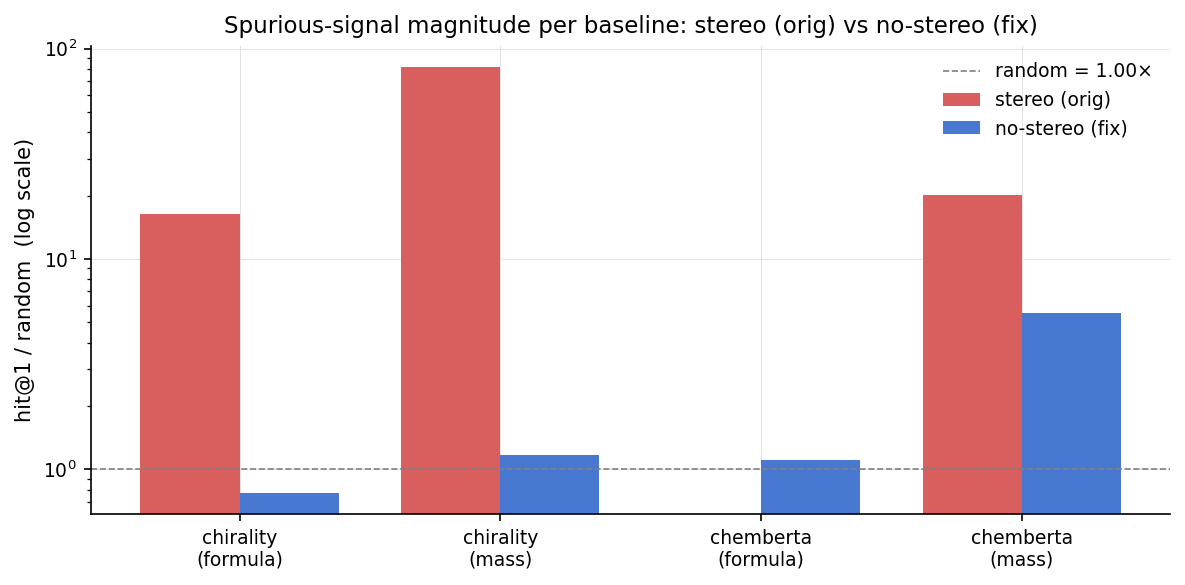

In [4]:
# Headline bar chart: × random ratio per (baseline, variant) for stereo vs nostereo, hit@1.
fig, ax = plt.subplots(figsize=(8, 4))
labels = []
ster_vals, nost_vals = [], []
for baseline in ['chirality', 'chemberta']:
    for variant in ['formula', 'mass']:
        labels.append(f'{baseline}\n({variant})')
        ster_v = df_headline.query('baseline == @baseline and variant == @variant and setting == "stereo"')['hit@1 / random'].values
        nost_v = df_headline.query('baseline == @baseline and variant == @variant and setting == "nostereo"')['hit@1 / random'].values
        ster_vals.append(ster_v[0] if len(ster_v) and not np.isnan(ster_v[0]) else 0.0)
        nost_vals.append(nost_v[0] if len(nost_v) and not np.isnan(nost_v[0]) else 0.0)

x = np.arange(len(labels))
w = 0.38
ax.bar(x - w/2, ster_vals, w, color='#D95F5F', label='stereo (orig)')
ax.bar(x + w/2, nost_vals, w, color='#4878CF', label='no-stereo (fix)')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='random = 1.00×')
ax.set_yscale('log')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('hit@1 / random  (log scale)')
ax.set_title('Spurious-signal magnitude per baseline: stereo (orig) vs no-stereo (fix)')
ax.legend(frameon=False); _despine(ax)
fig.tight_layout()
_save(fig, 'spurious_signal_ratio')
plt.show()

## Per-step ablation (nostereo only) — per-feature ranking baselines

For each augmentation step (S4 only / S4+PC / S4+PC+Mol) we score
candidates by 8 simple SMILES features and report hit@1 / random.

In [5]:
DIAG = {
    'formula_S4only':           OUT / 'diagnose_residual_formula_S4only_nostereo.pkl',
    'formula_S4plusPC':         OUT / 'diagnose_residual_formula_S4plusPC_nostereo.pkl',
    'formula_S4plusPCplusMol':  OUT / 'diagnose_residual_formula_nostereo.pkl',
    'mass_S4only':              OUT / 'diagnose_residual_mass_S4only_nostereo.pkl',
    'mass_S4plusPC':            OUT / 'diagnose_residual_mass_nostereo.pkl',
}

# Map to the matching nostereo random baseline key.
DIAG_TO_BASELINE = {
    'formula_S4only':           'formula_nostereo_S4only',
    'formula_S4plusPC':         'formula_nostereo_S4plusPC',
    'formula_S4plusPCplusMol':  'formula_nostereo_S4plusPCplusMol',
    'mass_S4only':              'mass_nostereo_S4only',
    'mass_S4plusPC':            'mass_nostereo_S4plusPC',
}

rows = []
for label, p in DIAG.items():
    with p.open('rb') as f: obj = pickle.load(f)
    perf = obj['perf']
    rb = baselines[DIAG_TO_BASELINE[label]]
    for _, row in perf.iterrows():
        rows.append({
            'variant': label, 'feature': row['feature'], 'direction': row['direction'],
            'hit@1 (%)':  row['hit@1 (%)'],  'random hit@1 (%)':  rb['random_hit@1'],
            'hit@1 ratio':  row['hit@1 (%)']  / rb['random_hit@1']  if rb['random_hit@1']  else float('nan'),
            'hit@5 ratio':  row['hit@5 (%)']  / rb['random_hit@5']  if rb['random_hit@5']  else float('nan'),
            'hit@20 ratio': row['hit@20 (%)'] / rb['random_hit@20'] if rb['random_hit@20'] else float('nan'),
        })
df_diag = pd.DataFrame(rows)
piv_r = df_diag.pivot_table(index='feature', columns='variant', values='hit@1 ratio', aggfunc='first').round(2)
piv_a = df_diag.pivot_table(index='feature', columns='variant', values='hit@1 (%)', aggfunc='first').round(2)
cols = ['formula_S4only', 'formula_S4plusPC', 'formula_S4plusPCplusMol', 'mass_S4only', 'mass_S4plusPC']
print('hit@1 / random ratio per feature × variant:')
display(piv_r[cols])
print('absolute hit@1 (%):')
display(piv_a[cols])

hit@1 / random ratio per feature × variant:


variant,formula_S4only,formula_S4plusPC,formula_S4plusPCplusMol,mass_S4only,mass_S4plusPC
feature,,,,,
aromatic_atoms,1.18,1.31,1.49,1.25,1.41
heavy_atoms,1.02,0.97,1.29,1.84,0.59
heteroatoms,0.99,1.04,1.02,0.99,1.06
length,0.90,0.72,0.60,0.47,0.35
max_ring_size,1.04,0.97,1.17,0.97,1.41
n_nitrogens,1.03,0.86,0.69,1.11,1.41
n_rings,1.08,1.08,1.31,0.83,1.41
n_unusual_elements,0.99,0.98,0.87,1.02,1.41


absolute hit@1 (%):


variant,formula_S4only,formula_S4plusPC,formula_S4plusPCplusMol,mass_S4only,mass_S4plusPC
feature,,,,,
aromatic_atoms,10.01,3.57,2.00,1.77,0.40
heavy_atoms,8.68,2.64,1.74,2.60,0.17
heteroatoms,8.34,2.84,1.37,1.40,0.30
length,7.64,1.97,0.80,0.67,0.10
max_ring_size,8.85,2.64,1.57,1.37,0.40
n_nitrogens,8.71,2.34,0.93,1.57,0.40
n_rings,9.15,2.94,1.77,1.17,0.40
n_unusual_elements,8.41,2.67,1.17,1.44,0.40


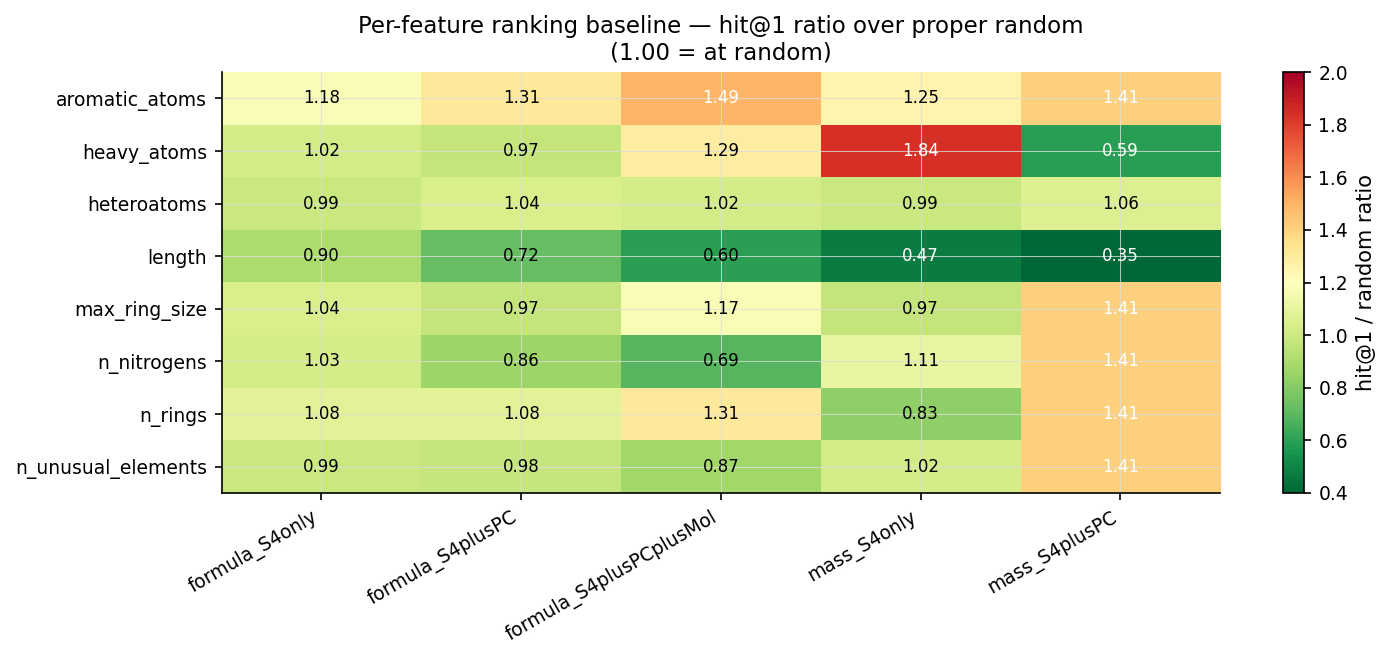

In [6]:
# Heatmap of ratios.
fig, ax = plt.subplots(figsize=(10, 4.5))
mat = piv_r[cols].values
im = ax.imshow(mat, aspect='auto', cmap='RdYlGn_r', vmin=0.4, vmax=2.0)
ax.set_xticks(np.arange(len(cols))); ax.set_xticklabels(cols, rotation=30, ha='right')
ax.set_yticks(np.arange(len(piv_r.index))); ax.set_yticklabels(piv_r.index)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f'{mat[i, j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(mat[i, j] - 1.0) > 0.4 else 'black')
fig.colorbar(im, ax=ax, label='hit@1 / random ratio')
ax.set_title('Per-feature ranking baseline — hit@1 ratio over proper random\n(1.00 = at random)')
fig.tight_layout()
_save(fig, 'per_feature_hit1_ratio_heatmap')
plt.show()

## Distribution comparison: queries vs final S4+PC+Mol pool

In [7]:
with (OUT / 'diagnose_residual_formula_nostereo.pkl').open('rb') as f:
    obj_f = pickle.load(f)
print('=== FORMULA final ===')
display(obj_f['dist'].round(3))
with (OUT / 'diagnose_residual_mass_nostereo.pkl').open('rb') as f:
    obj_m = pickle.load(f)
print('=== MASS final ===')
display(obj_m['dist'].round(3))

=== FORMULA final ===


,feature,GT mean,GT median,GT p10,GT p90,POOL mean,POOL median,POOL p10,POOL p90,Δ mean (GT-POOL)
0,length,58.379,54.0,39.0,86.0,45.212,43.0,30.0,61.0,13.167
1,heavy_atoms,33.369,31.0,23.0,48.0,26.560,26.0,18.0,35.0,6.810
2,n_rings,3.993,4.0,2.0,6.0,3.220,3.0,2.0,5.0,0.773
3,aromatic_atoms,13.538,15.0,0.0,22.0,11.263,12.0,0.0,18.0,2.274
4,heteroatoms,9.102,8.0,6.0,14.0,6.533,6.0,4.0,9.0,2.570
5,n_unusual_elements,0.002,0.0,0.0,0.0,0.001,0.0,0.0,0.0,0.001
6,max_ring_size,6.520,6.0,6.0,7.0,6.085,6.0,6.0,7.0,0.436
7,n_nitrogens,3.437,3.0,0.0,6.0,2.122,2.0,0.0,5.0,1.315


=== MASS final ===


,feature,GT mean,GT median,GT p10,GT p90,POOL mean,POOL median,POOL p10,POOL p90,Δ mean (GT-POOL)
0,length,58.379,54.0,39.0,86.0,45.998,45.0,30.0,63.0,12.380
1,heavy_atoms,33.369,31.0,23.0,48.0,26.979,26.0,18.0,36.0,6.390
2,n_rings,3.993,4.0,2.0,6.0,3.296,3.0,2.0,5.0,0.697
3,aromatic_atoms,13.538,15.0,0.0,22.0,12.043,12.0,0.0,21.0,1.494
4,heteroatoms,9.102,8.0,6.0,14.0,6.844,7.0,4.0,10.0,2.258
5,n_unusual_elements,0.002,0.0,0.0,0.0,0.001,0.0,0.0,0.0,0.001
6,max_ring_size,6.520,6.0,6.0,7.0,6.014,6.0,6.0,6.0,0.506
7,n_nitrogens,3.437,3.0,0.0,6.0,2.435,2.0,0.0,5.0,1.002


## Operational guidance

1. **For any retrieval evaluation against S4-generated candidates**, apply
   `massspecgym.utils.strip_stereo_{tsv,mgf,candidates_json}` to both the
   query data file (.tsv / .mgf) and the candidate JSON, then use the
   `*_nostereo` siblings. The stereo-asymmetry shortcut is gone.
2. **The Spectraverse-based standardizer in `dreams_mol`** now exposes
   `strip_stereo: bool = True` (default True, matches MERLIN_Apr2026
   behaviour). Set False only when you have a stereo-aware pipeline end
   to end — including a stereo-aware candidate generator.
3. **ChemBERTa mass nostereo (5.6× random)** is the only remaining
   spectrum-free signal. If mass-based retrieval becomes a primary
   benchmark, do an n-gram / token-frequency diagnostic on it.

**Pickle locations** (all in `data/test_results_v1.5/retrieval/`):
`chirality_{formula,mass}{,_nostereo}.pkl`,
`chemberta_{formula,mass}{,_nostereo}.pkl`,
`diagnose_residual_{formula,mass}_{,S4only_,S4plusPC_}nostereo.pkl`.